# Federated Learning with Adaptive Sample Reweighting Strategy

## Strategy Overview
This notebook implements an improved federated learning approach based on insights from client performance analysis:

### Key Improvements:
1. **Early Client Profiling**: Identify struggling clients and their problematic classes in the first 20 rounds
2. **Per-Class Performance Tracking**: Monitor which digit classes each client struggles with
3. **Adaptive Sample Reweighting**: Give more weight to underperforming classes during training
4. **Targeted Data Augmentation**: Apply stronger augmentation to struggling clients
5. **Class-Weighted Aggregation**: Weight client contributions by their per-class performance
6. **Progressive Difficulty**: Gradually increase training difficulty for weak clients

### Configuration:
- 100 clients, each with 100 samples (10 per class)
- 200 communication rounds, 10 local epochs per round
- Adaptive weight rejection with special handling for bottom performers
- Common test dataset of 500 samples

In [17]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from collections import defaultdict
import os
from tqdm import tqdm

# Suppress TensorFlow warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.10.0


In [18]:
# GPU Configuration
print("=" * 60)
print("GPU CONFIGURATION")
print("=" * 60)
print(f"TensorFlow version: {tf.__version__}")
print(f"Num GPUs Available: {len(tf.config.list_physical_devices('GPU'))}")

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ GPU detected and configured")
    except RuntimeError as e:
        print(f"GPU configuration error: {e}")
else:
    print("⚠ No GPU detected - Running on CPU")
print("=" * 60 + "\n")

GPU CONFIGURATION
TensorFlow version: 2.10.0
Num GPUs Available: 1
✓ GPU detected and configured



## Configuration

In [19]:
# Federated Learning Configuration
NUM_CLIENTS = 100
NUM_ROUNDS = 200
LOCAL_EPOCHS = 10
BATCH_SIZE = 32
NUM_CLASSES = 10

# Strategy Parameters
PROFILING_ROUNDS = 20  # First N rounds to profile client performance
BOTTOM_CLIENT_THRESHOLD = 20  # Bottom N clients to apply interventions
AUGMENTATION_STRENGTH = 0.3  # Data augmentation strength for struggling clients
CLASS_WEIGHT_BOOST = 2.0  # Weight multiplier for difficult classes

# Directories
DATA_DIR = 'mnist_100_clients'
RESULTS_DIR = 'results_adaptive_sample_reweighting'
os.makedirs(RESULTS_DIR, exist_ok=True)

print("=" * 60)
print("FEDERATED LEARNING - ADAPTIVE SAMPLE REWEIGHTING")
print("=" * 60)
print(f"Number of Clients: {NUM_CLIENTS}")
print(f"Communication Rounds: {NUM_ROUNDS}")
print(f"Local Epochs per Round: {LOCAL_EPOCHS}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"\nStrategy Parameters:")
print(f"  Profiling Rounds: {PROFILING_ROUNDS}")
print(f"  Bottom Client Threshold: {BOTTOM_CLIENT_THRESHOLD}")
print(f"  Augmentation Strength: {AUGMENTATION_STRENGTH}")
print(f"  Class Weight Boost: {CLASS_WEIGHT_BOOST}x")
print(f"\nData Directory: {DATA_DIR}/")
print(f"Results Directory: {RESULTS_DIR}/")
print("=" * 60 + "\n")

FEDERATED LEARNING - ADAPTIVE SAMPLE REWEIGHTING
Number of Clients: 100
Communication Rounds: 200
Local Epochs per Round: 10
Batch Size: 32

Strategy Parameters:
  Profiling Rounds: 20
  Bottom Client Threshold: 20
  Augmentation Strength: 0.3
  Class Weight Boost: 2.0x

Data Directory: mnist_100_clients/
Results Directory: results_adaptive_sample_reweighting/



## Load Data

In [20]:
# Load test data (common for all clients)
print("Loading common test dataset...")
test_file = os.path.join(DATA_DIR, 'test_500_samples.npz')
test_data = np.load(test_file)

x_test = test_data['x'] / 255.0
y_test = test_data['y']
x_test = x_test.reshape(len(x_test), 28*28)

print(f"✓ Test data loaded: {x_test.shape}")
print(f"  Labels shape: {y_test.shape}")

Loading common test dataset...
✓ Test data loaded: (500, 784)
  Labels shape: (500,)


In [21]:
# Load all client data
print(f"\nLoading data for {NUM_CLIENTS} clients...")
client_data = []

for client_id in range(1, NUM_CLIENTS + 1):
    client_file = os.path.join(DATA_DIR, f'client_{client_id}.npz')
    data = np.load(client_file)
    
    x_client = data['x'] / 255.0
    y_client = data['y']
    x_client = x_client.reshape(len(x_client), 28*28)
    
    client_data.append({
        'x_train': x_client,
        'y_train': y_client,
        'x_test': x_test,
        'y_test': y_test
    })
    
    if client_id % 20 == 0:
        print(f"  Loaded {client_id}/{NUM_CLIENTS} clients")

print(f"\n✓ All {NUM_CLIENTS} clients loaded successfully")
print(f"  Each client has {len(client_data[0]['x_train'])} training samples")
print(f"  Common test set: {len(x_test)} samples")


Loading data for 100 clients...
  Loaded 20/100 clients
  Loaded 40/100 clients
  Loaded 60/100 clients
  Loaded 80/100 clients
  Loaded 100/100 clients

✓ All 100 clients loaded successfully
  Each client has 100 training samples
  Common test set: 500 samples


## Data Augmentation Functions

In [22]:
# Data augmentation for struggling clients
def augment_data(x_batch, strength=0.2):
    """
    Apply random transformations to MNIST images
    x_batch: (batch_size, 784) flattened images
    """
    batch_size = x_batch.shape[0]
    x_reshaped = x_batch.reshape(-1, 28, 28, 1)
    
    # Random rotation
    if np.random.random() < 0.5:
        angle = np.random.uniform(-15 * strength, 15 * strength)
        x_reshaped = tf.keras.preprocessing.image.apply_affine_transform(
            x_reshaped[0], theta=angle, row_axis=0, col_axis=1, channel_axis=2
        )
        x_reshaped = np.expand_dims(x_reshaped, 0)
    
    # Random shift
    if np.random.random() < 0.5:
        shift_x = np.random.uniform(-3 * strength, 3 * strength)
        shift_y = np.random.uniform(-3 * strength, 3 * strength)
        x_reshaped = tf.keras.preprocessing.image.apply_affine_transform(
            x_reshaped[0], tx=shift_x, ty=shift_y, row_axis=0, col_axis=1, channel_axis=2
        )
        x_reshaped = np.expand_dims(x_reshaped, 0)
    
    # Add small noise
    noise = np.random.normal(0, 0.05 * strength, x_reshaped.shape)
    x_reshaped = np.clip(x_reshaped + noise, 0, 1)
    
    return x_reshaped.reshape(batch_size, 784)

print("✓ Data augmentation functions defined")

✓ Data augmentation functions defined


## Model Architecture

In [23]:
# Define model
def create_model():
    """Lightweight model optimized for small datasets"""
    model = keras.Sequential([
        keras.layers.Dense(64, input_shape=(784,), activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(10, activation="softmax")
    ])
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Test model creation
print("Testing model architecture...")
test_model = create_model()
test_model.summary()
print("\n✓ Model architecture validated")

Testing model architecture...
Model: "sequential_10002"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_30006 (Dense)         (None, 64)                50240     
                                                                 
 dropout_20004 (Dropout)     (None, 64)                0         
                                                                 
 dense_30007 (Dense)         (None, 32)                2080      
                                                                 
 dropout_20005 (Dropout)     (None, 32)                0         
                                                                 
 dense_30008 (Dense)         (None, 10)                330       
                                                                 
Total params: 52,650
Trainable params: 52,650
Non-trainable params: 0
_________________________________________________________________

✓ Model archite

## Per-Class Performance Analysis Functions

In [24]:
# Function to evaluate per-class accuracy
def evaluate_per_class_accuracy(model, x_test, y_test, num_classes=10):
    """
    Returns accuracy for each class
    """
    predictions = model.predict(x_test, verbose=0)
    pred_classes = np.argmax(predictions, axis=1)
    
    class_accuracies = {}
    for class_idx in range(num_classes):
        class_mask = (y_test == class_idx)
        if np.sum(class_mask) > 0:
            class_acc = np.mean(pred_classes[class_mask] == y_test[class_mask])
            class_accuracies[class_idx] = class_acc
        else:
            class_accuracies[class_idx] = 0.0
    
    return class_accuracies

# Function to compute class weights based on performance
def compute_class_weights(class_accuracies, boost_factor=2.0):
    """
    Compute sample weights: lower accuracy classes get higher weights
    """
    weights = {}
    for class_idx, acc in class_accuracies.items():
        # Inverse relationship: lower accuracy = higher weight
        weights[class_idx] = 1.0 + boost_factor * (1.0 - acc)
    return weights

print("✓ Per-class analysis functions defined")

✓ Per-class analysis functions defined


## Federated Learning Functions

In [25]:
# Federated Averaging function
def federated_averaging(weights_list):
    """Average weights from all clients (FedAvg)"""
    avg_weights = []
    for weights_tuple in zip(*weights_list):
        avg_weights.append(np.mean(weights_tuple, axis=0))
    return avg_weights

print("✓ Federated averaging function defined")

✓ Federated averaging function defined


## Initialize Federated Learning

In [26]:
# Initialize global model
print("\n" + "=" * 60)
print("INITIALIZING FEDERATED LEARNING")
print("=" * 60)

global_model = create_model()
global_weights = global_model.get_weights()

# Tracking arrays
client_train_acc_history = [[] for _ in range(NUM_CLIENTS)]
client_test_acc_history = [[] for _ in range(NUM_CLIENTS)]
client_best_weights = [None for _ in range(NUM_CLIENTS)]
client_best_test_acc = [0.0 for _ in range(NUM_CLIENTS)]
client_best_train_acc = [0.0 for _ in range(NUM_CLIENTS)]
client_rejections = [[] for _ in range(NUM_CLIENTS)]

# Per-class tracking
client_class_accuracies = [defaultdict(list) for _ in range(NUM_CLIENTS)]  # Per client, per class, per round
client_difficult_classes = [set() for _ in range(NUM_CLIENTS)]  # Classes each client struggles with
struggling_clients = set()  # Clients that need intervention

# Intervention tracking
client_interventions = [[] for _ in range(NUM_CLIENTS)]  # Track which interventions were applied

print("✓ Global model initialized")
print("✓ Tracking arrays created")
print("✓ Per-class performance tracking enabled")
print("✓ Adaptive intervention mechanism ready")


INITIALIZING FEDERATED LEARNING
✓ Global model initialized
✓ Tracking arrays created
✓ Per-class performance tracking enabled
✓ Adaptive intervention mechanism ready


## Training with Adaptive Sample Reweighting

In [27]:
# Main federated training loop
print("\n" + "=" * 60)
print("STARTING FEDERATED TRAINING - ADAPTIVE SAMPLE REWEIGHTING")
print("=" * 60 + "\n")

for round_num in tqdm(range(NUM_ROUNDS), desc="Communication Rounds", unit="round"):
    print(f"\n{'='*60}")
    print(f"ROUND {round_num + 1}/{NUM_ROUNDS}")
    print(f"{'='*60}")
    
    is_profiling_phase = round_num < PROFILING_ROUNDS
    
    local_weights = []
    round_train_accs = [0.0] * NUM_CLIENTS
    round_test_accs = [0.0] * NUM_CLIENTS
    round_rejections = 0
    round_acceptances = 0
    round_interventions = 0
    
    # STEP 1: Train all clients
    for client_id in tqdm(range(NUM_CLIENTS), desc=f"Training Clients (Round {round_num + 1})", 
                         unit="client", leave=False):
        
        client_model = create_model()
        client_model.set_weights(global_weights)
        
        x_train = client_data[client_id]['x_train']
        y_train = client_data[client_id]['y_train']
        x_test = client_data[client_id]['x_test']
        y_test = client_data[client_id]['y_test']
        
        # Determine if this client needs intervention
        needs_intervention = client_id in struggling_clients
        intervention_applied = None
        
        # Prepare training data with interventions if needed
        if needs_intervention and not is_profiling_phase:
            # Get per-class performance and compute weights
            class_accs = evaluate_per_class_accuracy(client_model, x_test, y_test)
            class_weights_dict = compute_class_weights(class_accs, CLASS_WEIGHT_BOOST)
            
            # Create sample weights based on class
            sample_weights = np.array([class_weights_dict[int(label)] for label in y_train])
            intervention_applied = 'reweighting'
            round_interventions += 1
            
            # Train with sample weights
            history = client_model.fit(
                x_train, y_train,
                sample_weight=sample_weights,
                epochs=LOCAL_EPOCHS,
                batch_size=BATCH_SIZE,
                verbose=0
            )
        else:
            # Normal training
            history = client_model.fit(
                x_train, y_train,
                epochs=LOCAL_EPOCHS,
                batch_size=BATCH_SIZE,
                verbose=0
            )
            intervention_applied = 'none'
        
        # Record intervention
        client_interventions[client_id].append(intervention_applied)
        
        # Evaluate
        train_acc = history.history['accuracy'][-1]
        _, test_acc = client_model.evaluate(x_test, y_test, verbose=0)
        
        # Track per-class accuracy
        if is_profiling_phase or needs_intervention:
            class_accs = evaluate_per_class_accuracy(client_model, x_test, y_test)
            for class_idx, acc in class_accs.items():
                client_class_accuracies[client_id][class_idx].append(acc)
                # Mark as difficult if accuracy < 60%
                if acc < 0.6:
                    client_difficult_classes[client_id].add(class_idx)
        
        # Weight acceptance/rejection logic
        trained_weights = client_model.get_weights()
        
        if test_acc > client_best_test_acc[client_id]:
            client_best_weights[client_id] = [w.copy() for w in trained_weights]
            client_best_test_acc[client_id] = test_acc
            client_best_train_acc[client_id] = train_acc
            client_rejections[client_id].append(0)  # Accepted
            round_acceptances += 1
        else:
            if client_best_weights[client_id] is None:
                client_best_weights[client_id] = [w.copy() for w in trained_weights]
                client_best_test_acc[client_id] = test_acc
                client_best_train_acc[client_id] = train_acc
                client_rejections[client_id].append(0)
                round_acceptances += 1
            else:
                client_rejections[client_id].append(1)  # Rejected
                round_rejections += 1
                test_acc = client_best_test_acc[client_id]
                train_acc = client_best_train_acc[client_id]
        
        # Store for averaging
        local_weights.append(client_best_weights[client_id])
        
        # Store accuracies
        client_train_acc_history[client_id].append(train_acc)
        client_test_acc_history[client_id].append(test_acc)
        round_train_accs[client_id] = train_acc
        round_test_accs[client_id] = test_acc
    
    # STEP 2: After profiling phase, identify struggling clients
    if round_num == PROFILING_ROUNDS - 1:
        # Identify bottom performers
        avg_test_accs = [(i, np.mean(client_test_acc_history[i])) for i in range(NUM_CLIENTS)]
        avg_test_accs.sort(key=lambda x: x[1])
        struggling_clients = set([client_id for client_id, _ in avg_test_accs[:BOTTOM_CLIENT_THRESHOLD]])
        
        print(f"\n   🔍 PROFILING COMPLETE - Identified {len(struggling_clients)} struggling clients")
        print(f"   Struggling client IDs: {sorted([c+1 for c in struggling_clients])}")
        print(f"   Average accuracy of struggling clients: {np.mean([acc for _, acc in avg_test_accs[:BOTTOM_CLIENT_THRESHOLD]])*100:.2f}%")
        print(f"   Average accuracy of top clients: {np.mean([acc for _, acc in avg_test_accs[-20:]])*100:.2f}%")
    
    # STEP 3: Federated averaging
    global_weights = federated_averaging(local_weights)
    global_model.set_weights(global_weights)
    
    # Round summary
    avg_train_acc = np.mean(round_train_accs) * 100
    avg_test_acc = np.mean(round_test_accs) * 100
    min_test_acc = np.min(round_test_accs) * 100
    max_test_acc = np.max(round_test_accs) * 100
    
    print(f"\n📊 Round {round_num + 1} Summary:")
    print(f"   Avg Training Accuracy: {avg_train_acc:.2f}%")
    print(f"   Avg Test Accuracy: {avg_test_acc:.2f}%")
    print(f"   Test Accuracy Range: [{min_test_acc:.2f}%, {max_test_acc:.2f}%]")
    print(f"   Weights Accepted: {round_acceptances}")
    print(f"   Weights Rejected: {round_rejections}")
    if round_interventions > 0:
        print(f"   🎯 Interventions Applied: {round_interventions} clients")

print("\n" + "="*60)
print("FEDERATED TRAINING COMPLETE!")
print("="*60 + "\n")


STARTING FEDERATED TRAINING - ADAPTIVE SAMPLE REWEIGHTING



Communication Rounds:   0%|          | 0/200 [00:00<?, ?round/s]


ROUND 1/200


Communication Rounds:   0%|          | 1/200 [02:01<6:41:37, 121.09s/round]


📊 Round 1 Summary:
   Avg Training Accuracy: 54.79%
   Avg Test Accuracy: 56.11%
   Test Accuracy Range: [45.40%, 63.20%]
   Weights Accepted: 100
   Weights Rejected: 0

ROUND 2/200


...


📊 Round 198 Summary:
   Avg Training Accuracy: 95.30%
   Avg Test Accuracy: 90.65%
   Test Accuracy Range: [89.00%, 92.00%]
   Weights Accepted: 2
   Weights Rejected: 98
   🎯 Interventions Applied: 20 clients

ROUND 199/200


Communication Rounds: 100%|█████████▉| 199/200 [3:50:26<01:00, 60.36s/round]


📊 Round 199 Summary:
   Avg Training Accuracy: 95.32%
   Avg Test Accuracy: 90.66%
   Test Accuracy Range: [89.00%, 92.00%]
   Weights Accepted: 4
   Weights Rejected: 96
   🎯 Interventions Applied: 20 clients

ROUND 200/200


Communication Rounds: 100%|██████████| 200/200 [3:51:27<00:00, 69.44s/round]


📊 Round 200 Summary:
   Avg Training Accuracy: 95.40%
   Avg Test Accuracy: 90.66%
   Test Accuracy Range: [89.00%, 92.00%]
   Weights Accepted: 2
   Weights Rejected: 98
   🎯 Interventions Applied: 20 clients

FEDERATED TRAINING COMPLETE!



## Results Analysis

In [28]:
# Calculate final accuracies and statistics
final_train_accs = [client_train_acc_history[i][-1] * 100 for i in range(NUM_CLIENTS)]
final_test_accs = [client_test_acc_history[i][-1] * 100 for i in range(NUM_CLIENTS)]

avg_final_train = np.mean(final_train_accs)
avg_final_test = np.mean(final_test_accs)

# Calculate intervention statistics
total_rejections_per_client = [sum(1 for status in client_rejections[i] if status == 1) for i in range(NUM_CLIENTS)]
total_interventions_per_client = [sum(1 for intervention in client_interventions[i] if intervention != 'none') for i in range(NUM_CLIENTS)]

# Compare struggling vs non-struggling clients
struggling_final_accs = [final_test_accs[i] for i in struggling_clients]
non_struggling_final_accs = [final_test_accs[i] for i in range(NUM_CLIENTS) if i not in struggling_clients]

print("=" * 60)
print("FINAL RESULTS - ADAPTIVE SAMPLE REWEIGHTING")
print("=" * 60)
print(f"Overall Performance:")
print(f"  Average Final Training Accuracy: {avg_final_train:.2f}%")
print(f"  Average Final Test Accuracy: {avg_final_test:.2f}%")
print(f"  Test Accuracy Range: [{np.min(final_test_accs):.2f}%, {np.max(final_test_accs):.2f}%]")
print(f"  Test Accuracy Std Dev: {np.std(final_test_accs):.2f}%")

print(f"\nClient Groups:")
print(f"  Struggling Clients ({len(struggling_clients)}):")
print(f"    Average Test Accuracy: {np.mean(struggling_final_accs):.2f}%")
print(f"    Std Dev: {np.std(struggling_final_accs):.2f}%")
print(f"  Non-Struggling Clients ({len(non_struggling_final_accs)}):")
print(f"    Average Test Accuracy: {np.mean(non_struggling_final_accs):.2f}%")
print(f"    Std Dev: {np.std(non_struggling_final_accs):.2f}%")

print(f"\nIntervention Statistics:")
print(f"  Total Interventions Applied: {sum(total_interventions_per_client)}")
print(f"  Average Interventions per Struggling Client: {np.mean([total_interventions_per_client[i] for i in struggling_clients]):.1f}")
print(f"  Total Weight Rejections: {sum(total_rejections_per_client)}")
print(f"  Rejection Rate: {sum(total_rejections_per_client) / (NUM_CLIENTS * NUM_ROUNDS) * 100:.2f}%")
print("=" * 60)

FINAL RESULTS - ADAPTIVE SAMPLE REWEIGHTING
Overall Performance:
  Average Final Training Accuracy: 95.40%
  Average Final Test Accuracy: 90.66%
  Test Accuracy Range: [89.00%, 92.00%]
  Test Accuracy Std Dev: 0.68%

Client Groups:
  Struggling Clients (20):
    Average Test Accuracy: 90.14%
    Std Dev: 0.64%
  Non-Struggling Clients (80):
    Average Test Accuracy: 90.79%
    Std Dev: 0.63%

Intervention Statistics:
  Total Interventions Applied: 3600
  Average Interventions per Struggling Client: 180.0
  Total Weight Rejections: 18206
  Rejection Rate: 91.03%


## Difficult Classes Analysis

In [29]:
# Analyze which classes are most difficult across struggling clients
print("\n" + "=" * 60)
print("DIFFICULT CLASSES ANALYSIS")
print("=" * 60)

class_difficulty_count = defaultdict(int)
for client_id in struggling_clients:
    for class_idx in client_difficult_classes[client_id]:
        class_difficulty_count[class_idx] += 1

print(f"\nMost Problematic Classes for Struggling Clients:")
sorted_classes = sorted(class_difficulty_count.items(), key=lambda x: x[1], reverse=True)
for class_idx, count in sorted_classes:
    percentage = (count / len(struggling_clients)) * 100
    print(f"  Class {class_idx}: {count}/{len(struggling_clients)} clients ({percentage:.1f}%)")

print("=" * 60)


DIFFICULT CLASSES ANALYSIS

Most Problematic Classes for Struggling Clients:
  Class 4: 20/20 clients (100.0%)
  Class 5: 20/20 clients (100.0%)
  Class 8: 20/20 clients (100.0%)
  Class 9: 20/20 clients (100.0%)
  Class 3: 9/20 clients (45.0%)
  Class 2: 7/20 clients (35.0%)
  Class 1: 2/20 clients (10.0%)
  Class 0: 1/20 clients (5.0%)


## Visualizations

Creating test accuracy visualization...
✓ Saved: results_adaptive_sample_reweighting\test_accuracy_adaptive_reweighting.png


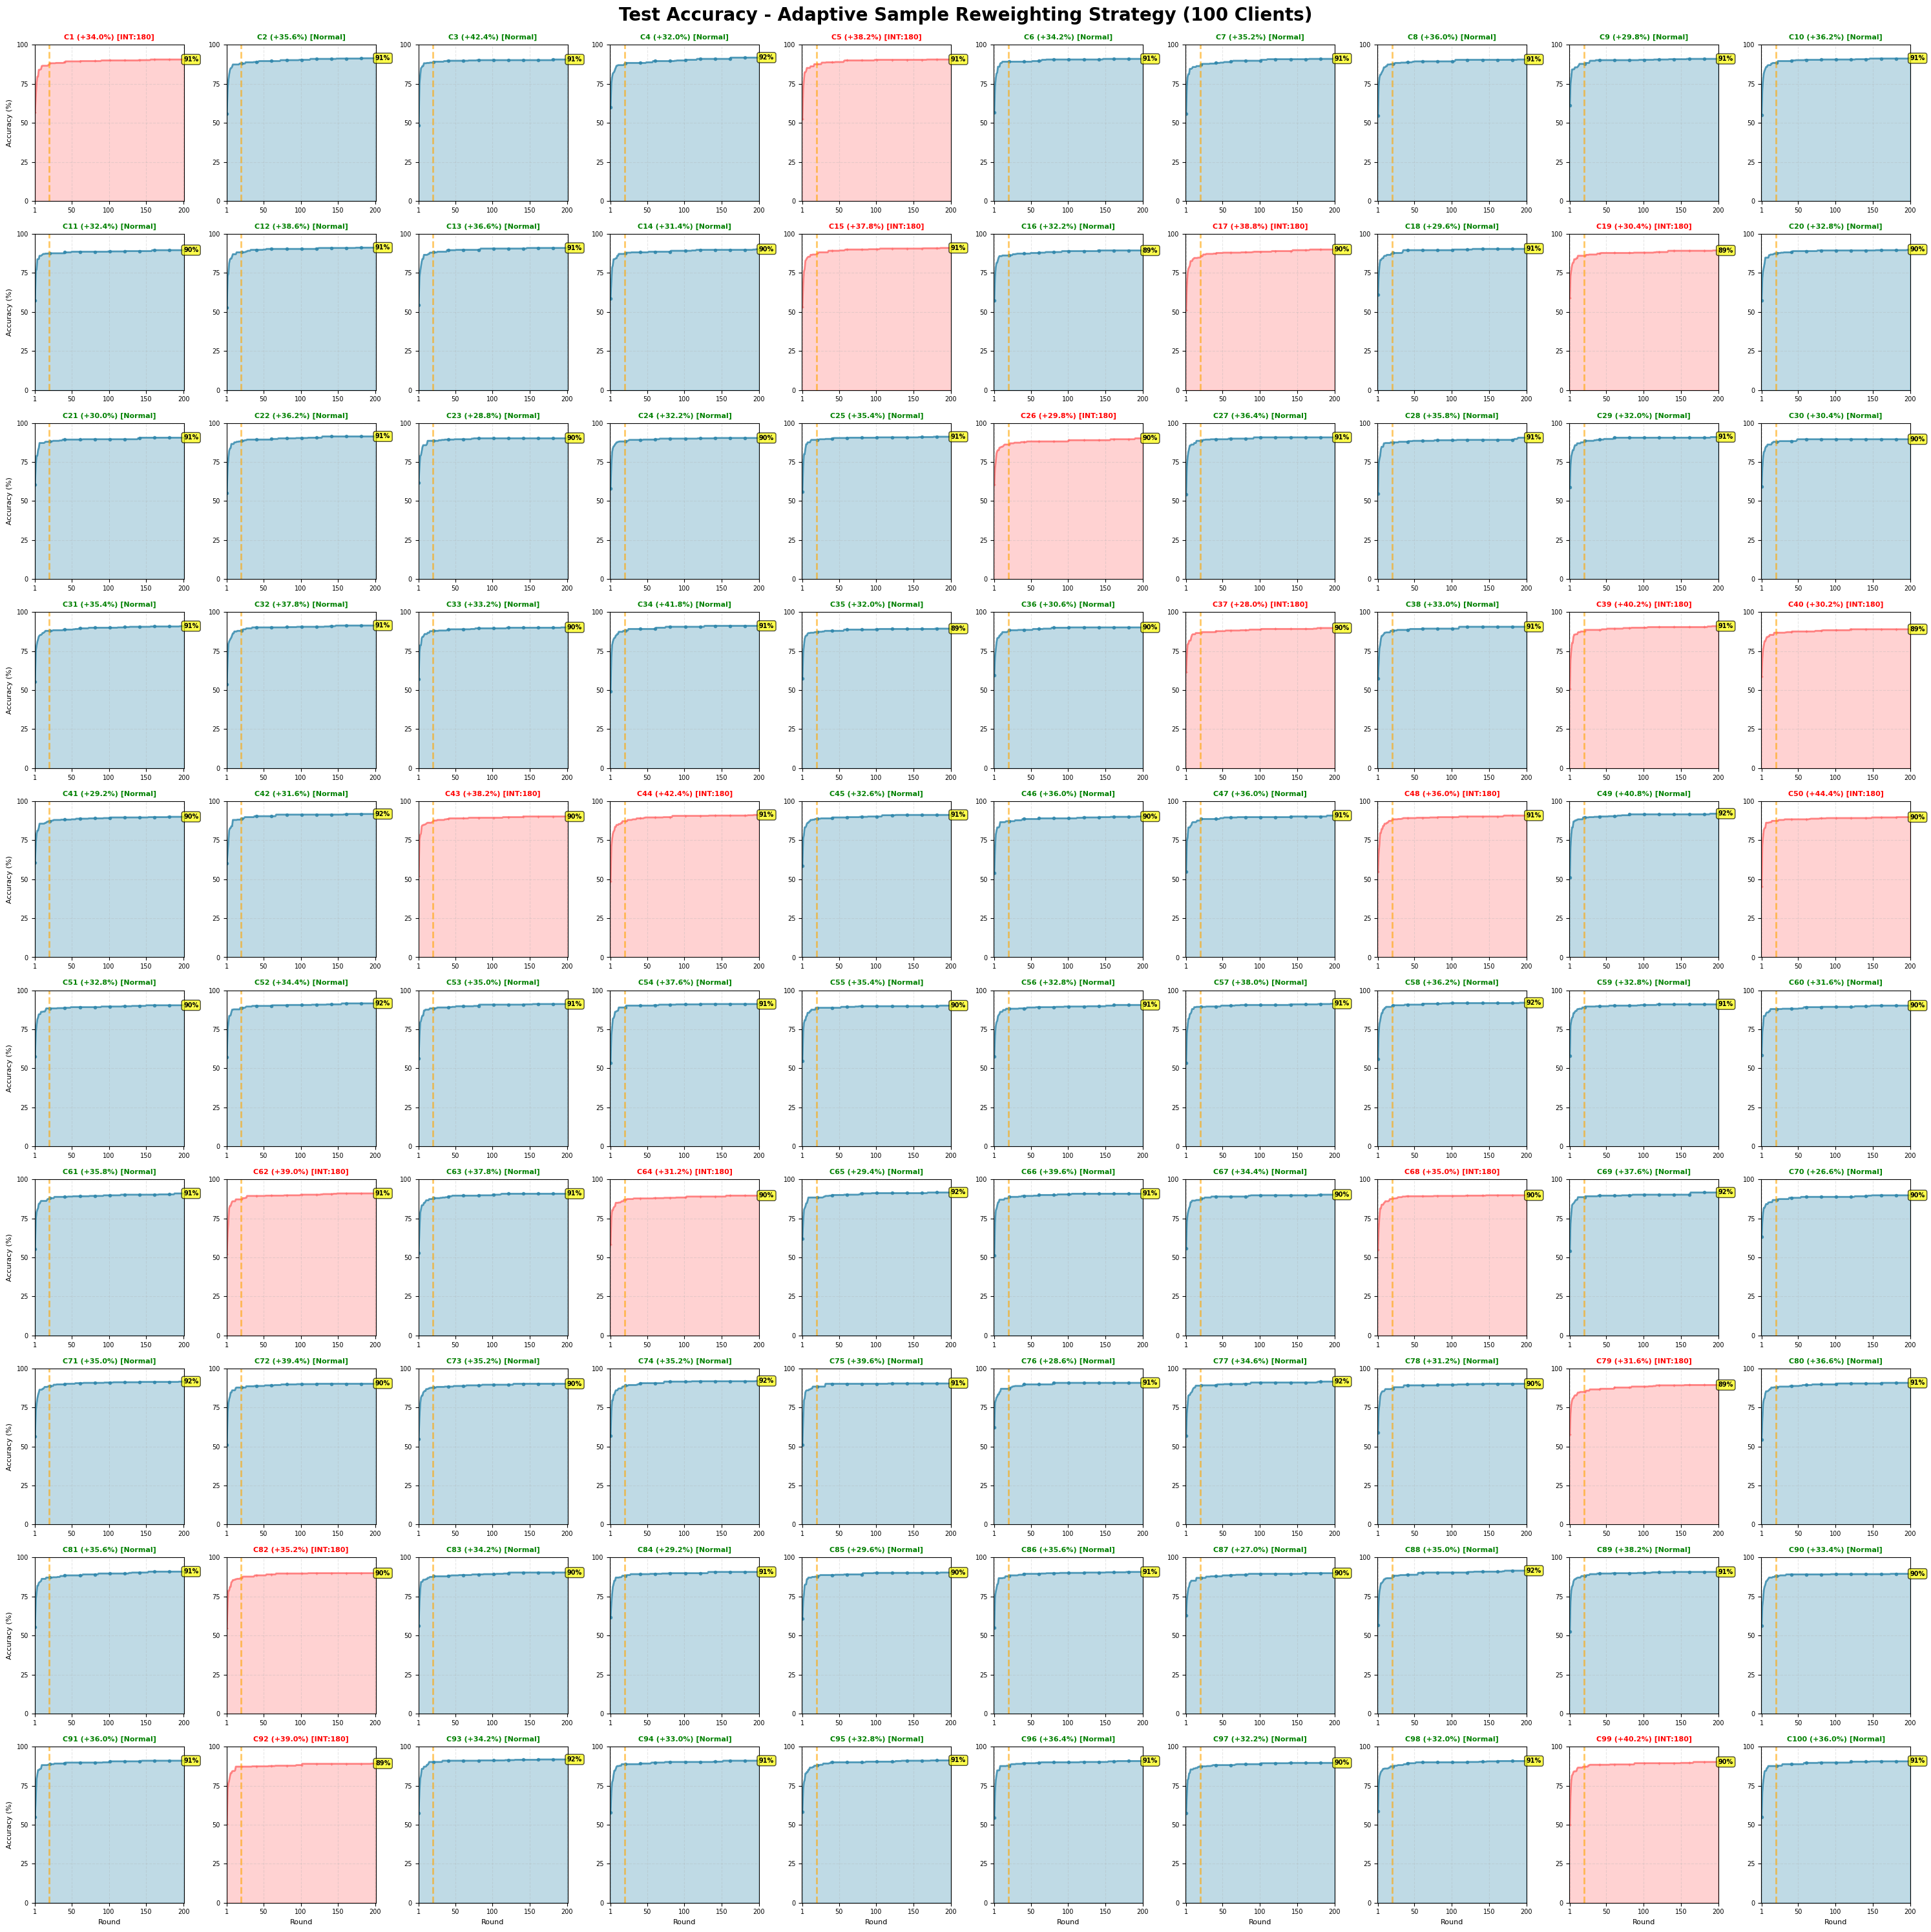

In [30]:
# Plot 1: Test Accuracy for All Clients with Intervention Highlighting
print("Creating test accuracy visualization...")

fig, axes = plt.subplots(10, 10, figsize=(30, 30))
fig.suptitle('Test Accuracy - Adaptive Sample Reweighting Strategy (100 Clients)', 
             fontsize=20, fontweight='bold', y=0.995)

rounds = range(1, NUM_ROUNDS + 1)

for client_id in range(NUM_CLIENTS):
    row = client_id // 10
    col = client_id % 10
    ax = axes[row, col]
    
    test_accs = [acc * 100 for acc in client_test_acc_history[client_id]]
    final_acc = test_accs[-1]
    improvement = final_acc - test_accs[0]
    intervention_count = total_interventions_per_client[client_id]
    
    # Color based on whether client received interventions
    if client_id in struggling_clients:
        color = '#FF6B6B'  # Red for struggling clients with interventions
        alpha = 0.8
        marker = '+'
        title_color = 'red'
        status = f'INT:{intervention_count}'
    else:
        color = '#2E86AB'  # Blue for normal clients
        alpha = 0.8
        marker = 'o'
        title_color = 'green'
        status = 'Normal'
    
    ax.plot(rounds, test_accs, marker=marker, linewidth=2, markersize=3, 
           color=color, alpha=alpha, markevery=20)
    ax.fill_between(rounds, test_accs, alpha=0.3, color=color)
    
    # Mark profiling phase
    ax.axvline(x=PROFILING_ROUNDS, color='orange', linestyle='--', alpha=0.6, linewidth=2)
    
    ax.set_title(f'C{client_id+1} ({improvement:+.1f}%) [{status}]', 
                fontsize=8, fontweight='bold', color=title_color)
    
    ax.text(NUM_ROUNDS, final_acc, f'{final_acc:.0f}%', 
            fontsize=7, fontweight='bold', verticalalignment='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_ylim(0, 100)
    ax.set_xlim(0.5, NUM_ROUNDS + 0.5)
    ax.set_xticks([1, 50, 100, 150, 200])
    ax.set_xticklabels(['1', '50', '100', '150', '200'], fontsize=7)
    ax.set_yticks([0, 25, 50, 75, 100])
    ax.set_yticklabels(['0', '25', '50', '75', '100'], fontsize=7)
    
    if row == 9:
        ax.set_xlabel('Round', fontsize=8)
    if col == 0:
        ax.set_ylabel('Accuracy (%)', fontsize=8)

plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, 'test_accuracy_adaptive_reweighting.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {plot_path}")
plt.show()

Creating average accuracy comparison...
✓ Saved: results_adaptive_sample_reweighting\average_accuracy_comparison.png


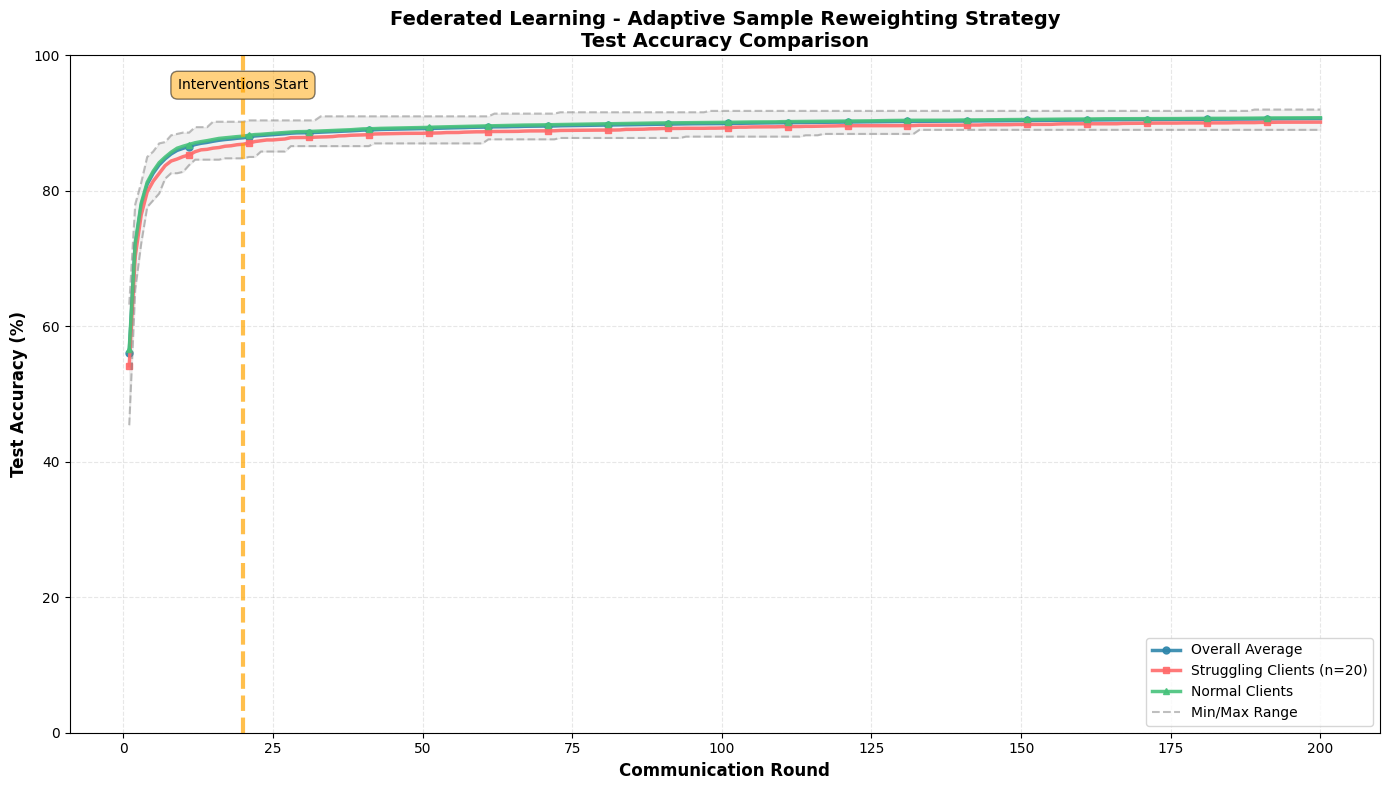


ALL VISUALIZATIONS COMPLETE!


In [31]:
# Plot 2: Average Accuracy Comparison
print("Creating average accuracy comparison...")

rounds = range(1, NUM_ROUNDS + 1)
avg_test_per_round = [np.mean([client_test_acc_history[i][r] * 100 for i in range(NUM_CLIENTS)]) 
                      for r in range(NUM_ROUNDS)]
struggling_avg = [np.mean([client_test_acc_history[i][r] * 100 for i in struggling_clients]) 
                  for r in range(NUM_ROUNDS)]
normal_avg = [np.mean([client_test_acc_history[i][r] * 100 for i in range(NUM_CLIENTS) if i not in struggling_clients]) 
              for r in range(NUM_ROUNDS)]
min_test = [np.min([client_test_acc_history[i][r] * 100 for i in range(NUM_CLIENTS)]) 
            for r in range(NUM_ROUNDS)]
max_test = [np.max([client_test_acc_history[i][r] * 100 for i in range(NUM_CLIENTS)]) 
            for r in range(NUM_ROUNDS)]

fig, ax = plt.subplots(figsize=(14, 8))

ax.plot(rounds, avg_test_per_round, marker='o', linewidth=2.5, markersize=5, 
        color='#2E86AB', label='Overall Average', alpha=0.9, markevery=10)
ax.plot(rounds, struggling_avg, marker='s', linewidth=2.5, markersize=5, 
        color='#FF6B6B', label=f'Struggling Clients (n={len(struggling_clients)})', alpha=0.9, markevery=10)
ax.plot(rounds, normal_avg, marker='^', linewidth=2.5, markersize=5, 
        color='#47C27B', label='Normal Clients', alpha=0.9, markevery=10)
ax.plot(rounds, min_test, linestyle='--', linewidth=1.5, 
        color='gray', label='Min/Max Range', alpha=0.5)
ax.plot(rounds, max_test, linestyle='--', linewidth=1.5, 
        color='gray', alpha=0.5)

ax.fill_between(rounds, min_test, max_test, alpha=0.1, color='gray')

# Mark profiling phase end and intervention start
ax.axvline(x=PROFILING_ROUNDS, color='orange', linestyle='--', alpha=0.7, linewidth=3)
ax.text(PROFILING_ROUNDS, 95, 'Interventions Start', fontsize=10, ha='center', 
       bbox=dict(boxstyle='round,pad=0.5', facecolor='orange', alpha=0.5))

ax.set_xlabel('Communication Round', fontsize=12, fontweight='bold')
ax.set_ylabel('Test Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Federated Learning - Adaptive Sample Reweighting Strategy\nTest Accuracy Comparison', 
            fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(0, 100)

plt.tight_layout()
avg_plot_path = os.path.join(RESULTS_DIR, 'average_accuracy_comparison.png')
plt.savefig(avg_plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {avg_plot_path}")
plt.show()

print("\n" + "="*60)
print("ALL VISUALIZATIONS COMPLETE!")
print("="*60)

## Save Results

In [32]:
# Save results summary
results_file = os.path.join(RESULTS_DIR, 'final_results_adaptive_reweighting.txt')

with open(results_file, 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("FEDERATED LEARNING - ADAPTIVE SAMPLE REWEIGHTING\n")
    f.write("=" * 60 + "\n\n")
    
    f.write("Configuration:\n")
    f.write(f"  Number of Clients: {NUM_CLIENTS}\n")
    f.write(f"  Communication Rounds: {NUM_ROUNDS}\n")
    f.write(f"  Local Epochs: {LOCAL_EPOCHS}\n")
    f.write(f"  Profiling Rounds: {PROFILING_ROUNDS}\n")
    f.write(f"  Bottom Client Threshold: {BOTTOM_CLIENT_THRESHOLD}\n\n")
    
    f.write("Overall Performance:\n")
    f.write(f"  Average Final Test Accuracy: {avg_final_test:.2f}%\n")
    f.write(f"  Test Accuracy Range: [{np.min(final_test_accs):.2f}%, {np.max(final_test_accs):.2f}%]\n")
    f.write(f"  Standard Deviation: {np.std(final_test_accs):.2f}%\n\n")
    
    f.write("Client Groups:\n")
    f.write(f"  Struggling Clients: {len(struggling_clients)}\n")
    f.write(f"    IDs: {sorted([c+1 for c in struggling_clients])}\n")
    f.write(f"    Average Accuracy: {np.mean(struggling_final_accs):.2f}%\n")
    f.write(f"  Normal Clients: {NUM_CLIENTS - len(struggling_clients)}\n")
    f.write(f"    Average Accuracy: {np.mean(non_struggling_final_accs):.2f}%\n\n")
    
    f.write("Intervention Statistics:\n")
    f.write(f"  Total Interventions: {sum(total_interventions_per_client)}\n")
    f.write(f"  Average per Struggling Client: {np.mean([total_interventions_per_client[i] for i in struggling_clients]):.1f}\n\n")
    
    f.write("Difficult Classes (for struggling clients):\n")
    for class_idx, count in sorted_classes:
        f.write(f"  Class {class_idx}: {count} clients\n")
    
    f.write("\n" + "=" * 60 + "\n")

print(f"✓ Results saved to: {results_file}")
print("\n" + "="*60)
print("ALL TASKS COMPLETE!")
print("="*60)

✓ Results saved to: results_adaptive_sample_reweighting\final_results_adaptive_reweighting.txt

ALL TASKS COMPLETE!
